# Plots for GCC Presentation!

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [3]:
# read in all metrics
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_full = xr.open_dataset(input_path)


In [4]:
# read in trend files

# SummerLength
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_LengthTrends.nc'
ds_length_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_LengthTrends.nc'
ds_length_trends_an = xr.open_dataset(input_path2)

# SummerStart
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_StartTrends.nc'
ds_start_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_StartTrends.nc'
ds_start_trends_an = xr.open_dataset(input_path2)

# SummerEnd
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_EndTrends.nc'
ds_end_trends = xr.open_dataset(input_path)

input_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_EndTrends.nc'
ds_end_trends_an = xr.open_dataset(input_path2)


In [5]:
# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_full.lat))
weights.name = "weights"

## Summer Length: Distribution of values and trends by latitude

In [8]:
# data for 1961-1990 Baseline period and 1990-2023 analysis period
length_base = ds_full.SummerLength.sel(time=slice('1961','1990'))
length_an = ds_full.SummerLength.sel(time=slice('1990','2023'))
#length_base, length_an

# plots by latitude bins - these are the lower end of 10 deg bins
lat_bins = [60,50,40,30,20,-30,-40,-50,-60,-70]

# one year of ds_full for extracting lsm and Coastal flags
# use mean to drop the time coordinate
ds_2023 = ds_full.sel(time=['2023']).mean(dim='time')
ds_2023['Coastal'] = ds_2023.Coastal.ascateg(bool)
#ds_coastal_2023 = ds_full.sel(time=['2023']).Coastal

levels = 2

### Boxplots instead of density for the trends

In [22]:
# thing = np.zeros(len(lat_bins))
# thing[0] = np.arange(0,10)
# thing
ds_full.SummerLength.sel(time=slice('1961','1971')).where((ds_full.lat >= 40) & 
                                                                      (ds_full.lat < 50)).weighted(weights).mean(dim=['lat','lon'])


<xarray.DataArray 'SummerLength' (time: 11)> Size: 88B
array([97.66293864, 91.75896336, 95.99868236, 78.57573849, 77.30599134,
       91.33562299, 94.42315291, 78.81241355, 80.15817177, 89.05297122,
       82.9414944 ])
Coordinates:
  * time     (time) datetime64[ns] 88B 1961-01-01 1962-01-01 ... 1971-01-01

In [29]:
land_base = np.zeros([len(lat_bins),30])
land_base[0,:]=np.arange(0,30)
land_base
#ds_full.time.dt.year.values

array([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,

In [78]:
%%time

# 13 seconds

land_base = np.zeros([len(lat_bins),30])
coast_base = np.zeros([len(lat_bins),30])
ocean_base = np.zeros([len(lat_bins),30])
land_an = np.zeros([len(lat_bins),34])
coast_an = np.zeros([len(lat_bins),34])
ocean_an = np.zeros([len(lat_bins),34])


# loop through all latitude buckets
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, KEEPING grid cells from averages where the mean summer temp was 0 K meaning no summer
    # since a length of zero is meaningful
    land_base[i,:] = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                             (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    coast_base[i,:] = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_base[i,:] = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_an[i,:] = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    land_an[i,:] = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                           (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    coast_an[i,:] = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])



# assemble dataframe of the data for plotting

a = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[0], 30),
                    'categ' : np.repeat('Land-Base', 30),
                  'period' : np.repeat('Base', 30),
                  'value': land_base[0,:]
                 })
b = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[0], 30),
                    'categ' : np.repeat('Coast-Base', 30),
                  'period' : np.repeat('Base', 30),
                  'value': coast_base[0,:]
                 })
c = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[0], 30),
                    'categ' : np.repeat('Ocean-Base', 30),
                  'period' : np.repeat('Base', 30),
                  'value': ocean_base[0,:]
                 })
d = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[0], 34),
                    'categ' : np.repeat('Land-Analysis', 34),
                  'period' : np.repeat('Analysis', 34),
                  'value': land_an[0,:]
                 })
e = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[0], 34),
                    'categ' : np.repeat('Coast-Analysis', 34),
                  'period' : np.repeat('Analysis', 34),
                  'value': coast_an[0,:]
                 })
f = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[0], 34),
                    'categ' : np.repeat('Ocean-Analysis', 34),
                  'period' : np.repeat('Analysis', 34),
                  'value': ocean_an[0,:]
                 })

for i in np.arange(1, len(lat_bins)):
    # baseline data groups
    ai = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[i], 30),
                       'categ' : np.repeat('Land-Base', 30),
                       'period' : np.repeat('Base', 30),
                       'value': land_base[i,:]
                     })
    a = pd.concat([a,ai], ignore_index=True)

    bi = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[i], 30),
                       'categ' : np.repeat('Coast-Base', 30),
                       'period' : np.repeat('Base', 30),
                       'value': coast_base[i,:]
                     })
    b = pd.concat([b,bi], ignore_index=True)

    ci = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[i], 30),
                       'categ' : np.repeat('Ocean-Base', 30),
                       'period' : np.repeat('Base', 30),
                       'value': ocean_base[i,:]
                     })
    c = pd.concat([c,ci], ignore_index=True)

    # analysis period data groups
    di = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[i], 34),
                       'categ' : np.repeat('Land-Analysis', 34),
                       'period' : np.repeat('Analysis', 34),
                       'value': land_an[i,:]
                     })
    d = pd.concat([d,di], ignore_index=True)

    ei = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[i], 34),
                       'categ' : np.repeat('Coast-Analysis', 34),
                       'period' : np.repeat('Analysis', 34),
                       'value': coast_an[i,:]
                     })
    e = pd.concat([e,ei], ignore_index=True)

    fi = pd.DataFrame({ 'lat_grp' : np.repeat(lat_bins[i], 34),
                       'categ' : np.repeat('Ocean-Analysis', 34),
                       'period' : np.repeat('Analysis', 34),
                       'value': ocean_an[i,:]
                     })
    f = pd.concat([f,fi], ignore_index=True)


df = pd.concat([a,b,c,d,e,f], ignore_index=True)
df



CPU times: user 8.18 s, sys: 4.08 s, total: 12.3 s
Wall time: 12.3 s


,lat_grp,categ,period,value
0,60,Land-Base,Base,75.092117
1,60,Land-Base,Base,69.230691
2,60,Land-Base,Base,64.319997
3,60,Land-Base,Base,66.644253
4,60,Land-Base,Base,63.168814
...,...,...,...,...
1915,-70,Ocean-Analysis,Analysis,84.546785
1916,-70,Ocean-Analysis,Analysis,60.389227
1917,-70,Ocean-Analysis,Analysis,64.915751
1918,-70,Ocean-Analysis,Analysis,80.888688


In [79]:
# function for filling boxes or not
def fill_bool(period):
    if (period == "Base"): return False
    else: return True


df['fill'] = df['period'].map(fill_bool)
df

,lat_grp,categ,period,value,fill
0,60,Land-Base,Base,75.092117,False
1,60,Land-Base,Base,69.230691,False
2,60,Land-Base,Base,64.319997,False
3,60,Land-Base,Base,66.644253,False
4,60,Land-Base,Base,63.168814,False
...,...,...,...,...,...
1915,-70,Ocean-Analysis,Analysis,84.546785,True
1916,-70,Ocean-Analysis,Analysis,60.389227,True
1917,-70,Ocean-Analysis,Analysis,64.915751,True
1918,-70,Ocean-Analysis,Analysis,80.888688,True


In [100]:
df1=df[df.period=='Base']
df2=df[df.period=='Analysis']
df1, df2

(     lat_grp       categ period      value   fill
 0         60   Land-Base   Base  75.092117  False
 1         60   Land-Base   Base  69.230691  False
 2         60   Land-Base   Base  64.319997  False
 3         60   Land-Base   Base  66.644253  False
 4         60   Land-Base   Base  63.168814  False
 ..       ...         ...    ...        ...    ...
 895      -70  Ocean-Base   Base  68.060309  False
 896      -70  Ocean-Base   Base  78.553502  False
 897      -70  Ocean-Base   Base  63.552419  False
 898      -70  Ocean-Base   Base  62.961601  False
 899      -70  Ocean-Base   Base  62.285794  False
 
 [900 rows x 5 columns],
       lat_grp           categ    period      value  fill
 900        60   Land-Analysis  Analysis  89.627474  True
 901        60   Land-Analysis  Analysis  91.114302  True
 902        60   Land-Analysis  Analysis  50.515831  True
 903        60   Land-Analysis  Analysis  78.581692  True
 904        60   Land-Analysis  Analysis  88.275107  True
 ...       ..

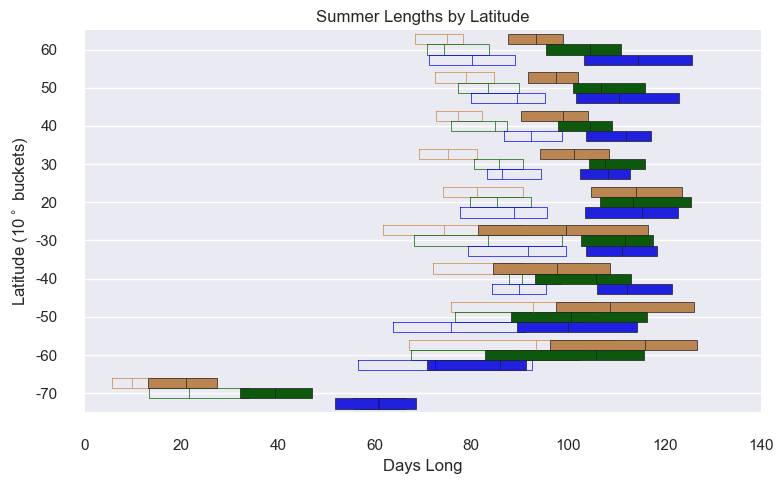

In [114]:
# create blank fig
fig = plt.figure(figsize = (8,5))
sns.set_theme(style="darkgrid")

# boxplot help: https://seaborn.pydata.org/examples/grouped_boxplot.html

# get the colors right
my_pal_colors = ["peru",  "darkgreen", "blue","peru",  "darkgreen", "blue"]

my_pal = {"Land-Base":"peru",  "Coast-Base":"darkgreen", "Ocean-Base":"blue",
          "Land-Analysis":"peru",  "Coast-Analysis":"darkgreen", "Ocean-Analysis":"blue"}

my_face = {"Land-Base":"none",  "Coast-Base":"none", "Ocean-Base":"none",
          "Land-Analysis":"peru",  "Coast-Analysis":"darkgreen", "Ocean-Analysis":"blue"}

# plot boxplot 

# sns.boxplot(x="value", y="lat_grp", data=df, hue="categ", 
#             palette=my_pal, orient='y', order=lat_bins, linewidth=0.5, fliersize=2) 

sns.boxplot(x="value", y="lat_grp", data=df1, hue="categ", fill=False, dodge=True, legend=False,
            palette=my_pal, orient='y', order=lat_bins, linewidth=0.5, fliersize=0, showcaps=False, whis=0) 
sns.boxplot(x="value", y="lat_grp", data=df2, hue="categ", dodge=True,legend=False,
            palette=my_pal, orient='y', order=lat_bins, linewidth=0.5, fliersize=0, showcaps=False, whis=0) 
plt.xlim(0,140)



# adding transparency to colors
# for patch in ax2.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))
sns.despine(offset=10, trim=True)    

plt.title("Summer Lengths by Latitude")
#ax2.legend(loc='upper left')
#ax2.set_xticks(np.arange(0,3,0.5))
#ax2.set_xlabel("Change in Summer Length (Days/Year)")
plt.xlabel("Days Long")
plt.ylabel("Latitude (10$^\circ$ buckets)")
plt.grid()
plt.tight_layout()
plt.show()

## full version with both lengths and trends

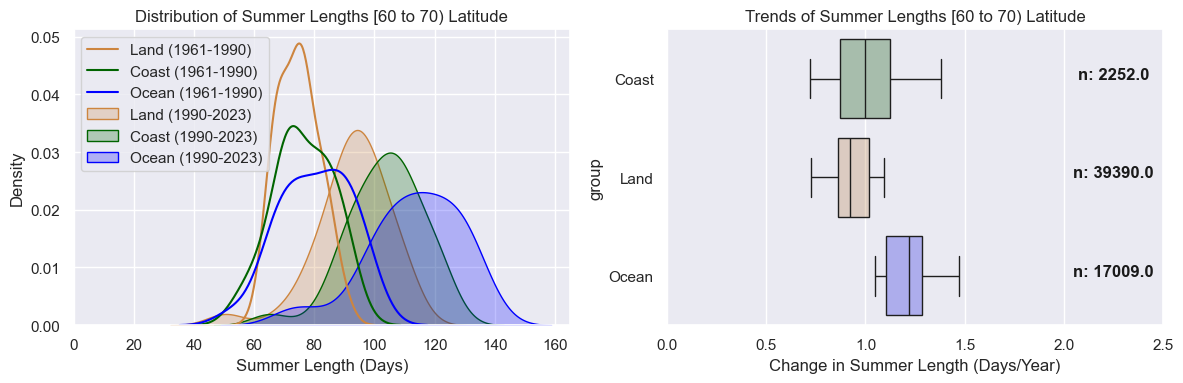

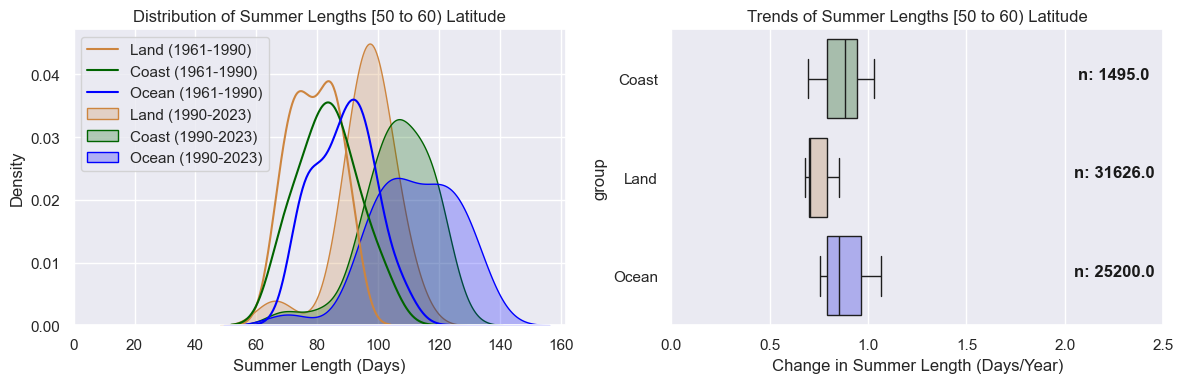

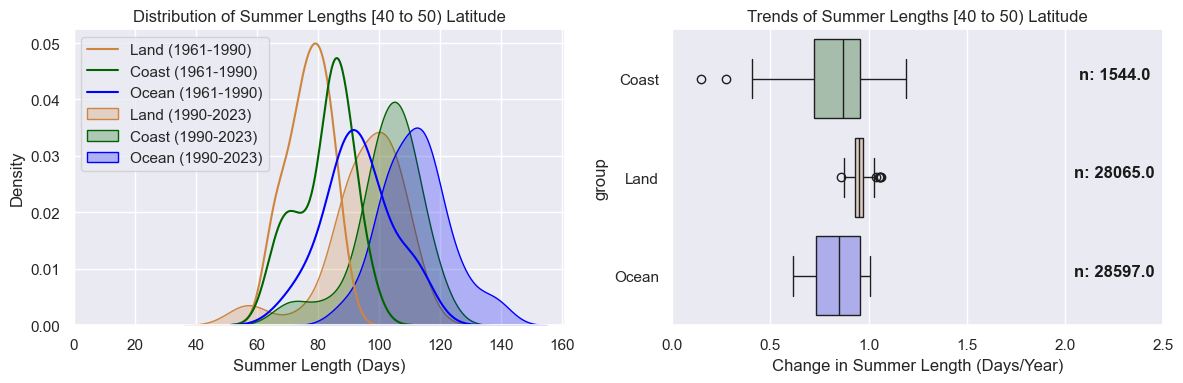

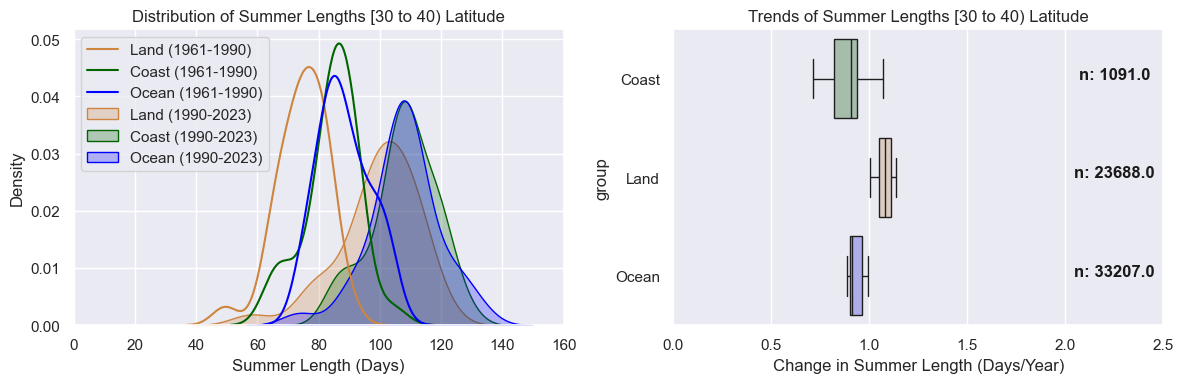

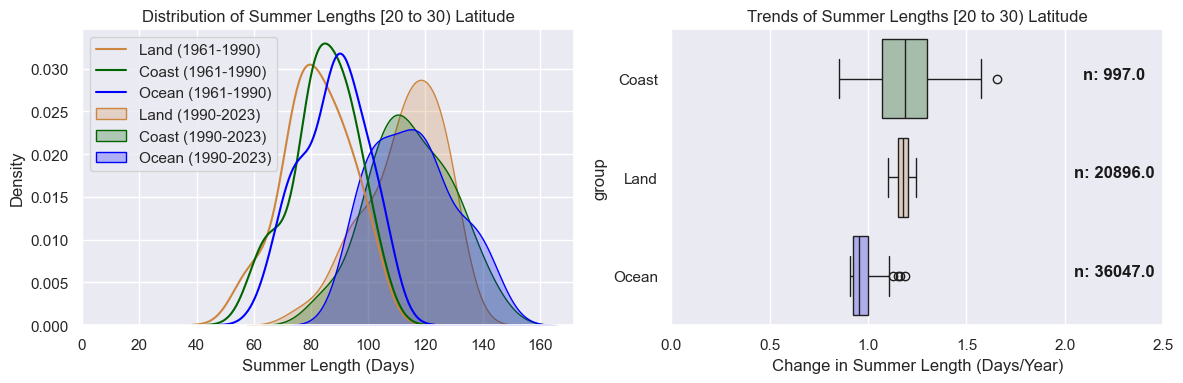

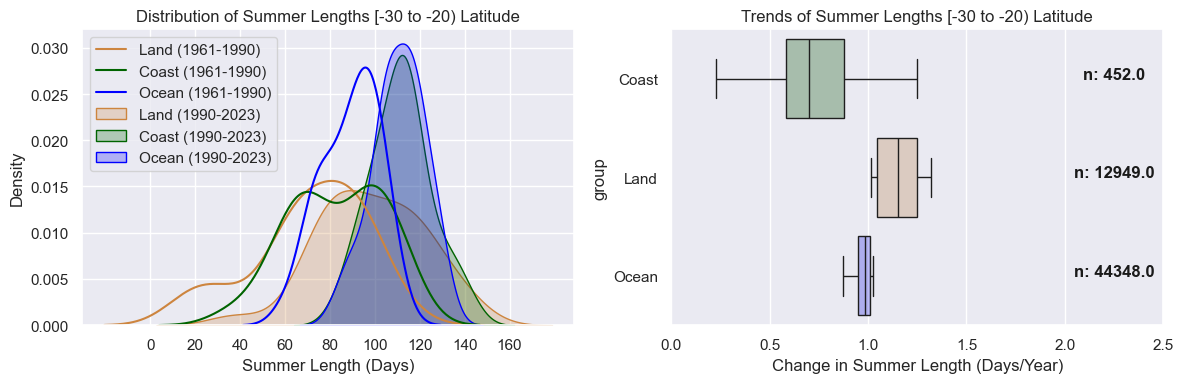

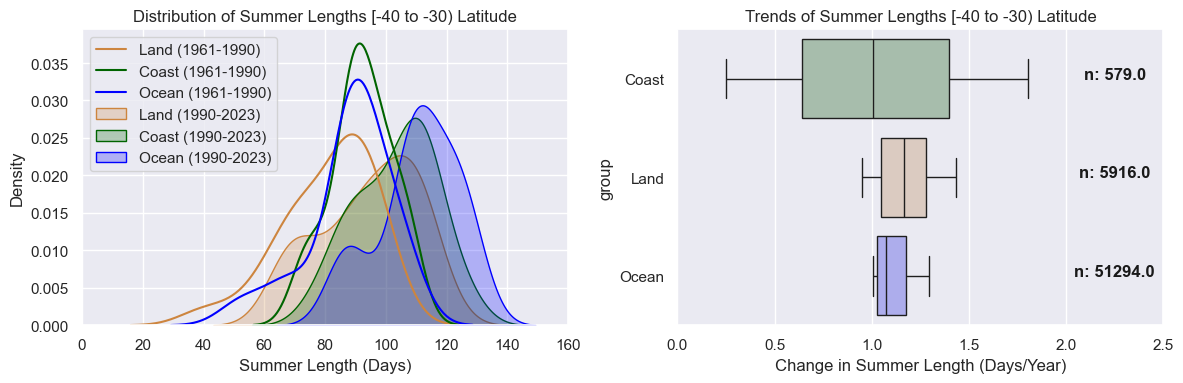

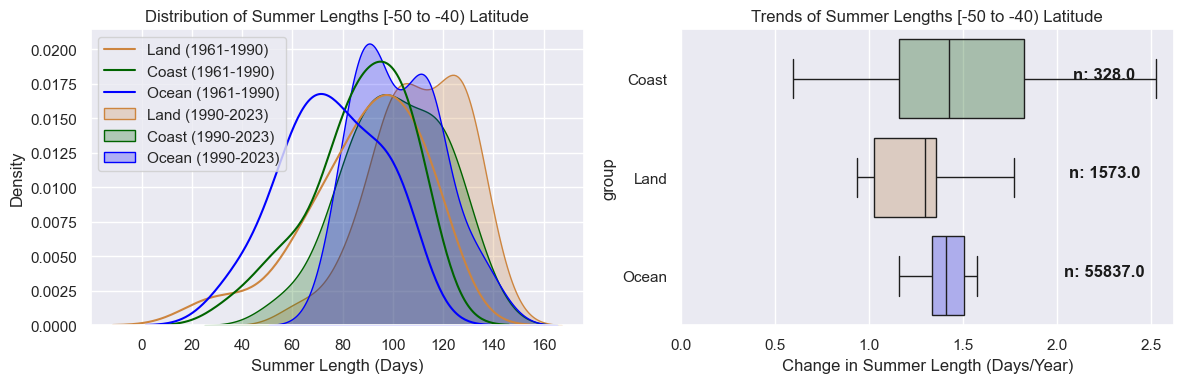

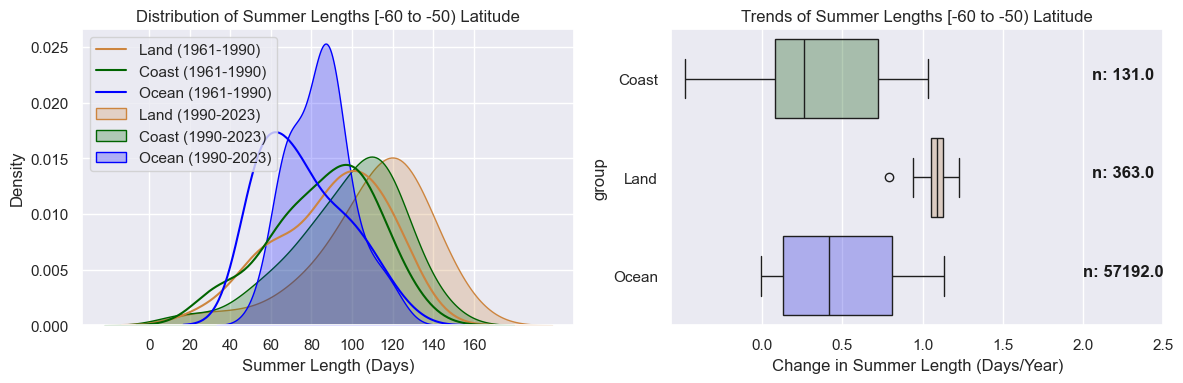

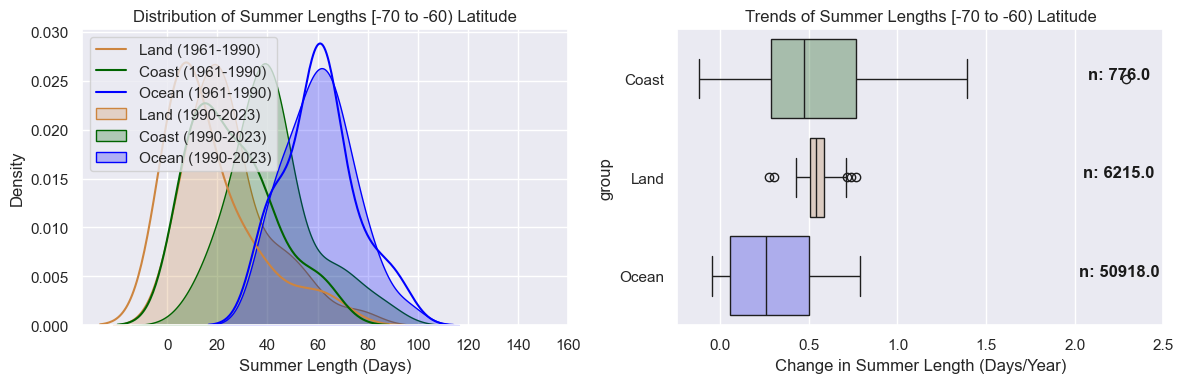

CPU times: user 9.98 s, sys: 4.39 s, total: 14.4 s
Wall time: 14.4 s


In [10]:
%%time


# loop through all latitude buckets
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, KEEPING grid cells from averages where the mean summer temp was 0 K meaning no summer
    land_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                             (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    coast_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    land_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                           (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    coast_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    # datasets of zonal trends for land, ocean, coasts during analysis period 
    # and number of grid cells for each classification for annotating the plot
    land_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm > 0.5) & (ds_2023.Coastal == False) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    num_land = np.count_nonzero(~np.isnan(ds_length_trends_an.LengthSlope.where((ds_2023.lsm > 0.5) & (ds_2023.Coastal == False) &
                                     ((ds_length_trends_an.lat >= v) & 
                                      (ds_length_trends_an.lat < (v+10))))))

    coast_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.Coastal) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    num_coast = np.count_nonzero(~np.isnan(ds_length_trends_an.LengthSlope.where((ds_2023.Coastal) & 
                                         ((ds_length_trends_an.lat >= v) & 
                                          (ds_length_trends_an.lat < (v+10))))))

    
    ocean_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_length_trends_an.lat >= v) & 
                                          (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    num_ocean = np.count_nonzero(~np.isnan(ds_length_trends_an.LengthSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_length_trends_an.lat >= v) & 
                                          (ds_length_trends_an.lat < (v+10))))))

    
    # create blank fig
    fig = plt.figure(figsize = (12,4))
    sns.set_theme(style="darkgrid")
    
    # Length value distributions
    #ax1 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,1)
    sns.kdeplot(land_base, fill=False, color="peru", label="Land (1961-1990)", levels=levels)
    sns.kdeplot(coast_base, fill=False, color="darkgreen", label="Coast (1961-1990)", levels=levels)
    sns.kdeplot(ocean_base, fill=False, color="blue", label="Ocean (1961-1990)", levels=levels)
    sns.kdeplot(land_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax1.set_title("Distribution of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    ax1.legend(loc='upper left')
    ax1.set_xticks(np.arange(0,180,20))
    ax1.set_xlabel("Summer Length (Days)")

    # Length trend distributions
    ax2 = fig.add_subplot(1,2,2)
    # boxplot help from https://python-graph-gallery.com/39-hidden-data-under-boxplot/
    # https://python-graph-gallery.com/33-control-colors-of-boxplot-seaborn/
    
    # Dataset:
    a = pd.DataFrame({ 'group' : np.repeat('Land', len(land_trends_an.values)),
                      'value': land_trends_an.values,
                     'nobs': np.repeat(num_land, len(land_trends_an.values))
                     })
    b = pd.DataFrame({ 'group' : np.repeat('Coast', len(land_trends_an.values)), 
                      'value': coast_trends_an.values,
                     'nobs': np.repeat(num_coast, len(land_trends_an.values))
                     })
    c = pd.DataFrame({ 'group' : np.repeat('Ocean', len(land_trends_an.values)), 
                      'value': ocean_trends_an.values,
                     'nobs': np.repeat(num_ocean, len(land_trends_an.values))
                     })
    df = pd.concat([b,a,c], ignore_index=True)

    # Calculate number of obs per group & median to position labels
    medians = df.groupby(['group'])['value'].median().values
    nobs = df.groupby(['group'])['nobs'].mean().values # all are the same so mean should be same
    
    nobs = [str(x) for x in nobs.tolist()]
    nobs = ["n: " + i for i in nobs]
    #print(nobs)

    # get the colors right
    my_pal = {"Land": "peru", "Ocean": "blue", "Coast":"darkgreen"}
    
    # plot boxplot 
    ax2 = sns.boxplot( x='value', y='group', data=df, hue='group', palette=my_pal)  

    # adding transparency to colors
    for patch in ax2.patches:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .3))
        
    # Add number of grid cells per class to the plot
    pos = range(len(nobs))
    for tick,label in zip(pos,ax2.get_yticklabels()):
        plt.text(2.25, pos[tick], nobs[tick], horizontalalignment='center', size='medium', color='k', weight='semibold')
  
    ax2.set_title("Trends of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    #ax2.legend(loc='upper left')
    ax2.set_xticks(np.arange(0,3,0.5))
    ax2.set_xlabel("Change in Summer Length (Days/Year)")

    plt.tight_layout()
    plt.show()

In [9]:
df

,group,value,nobs
0,Coast,NaN,776
1,Coast,NaN,776
2,Coast,NaN,776
3,Coast,NaN,776
4,Coast,NaN,776
...,...,...,...
2158,Ocean,NaN,50918
2159,Ocean,NaN,50918
2160,Ocean,NaN,50918
2161,Ocean,NaN,50918


## old version with kde for both

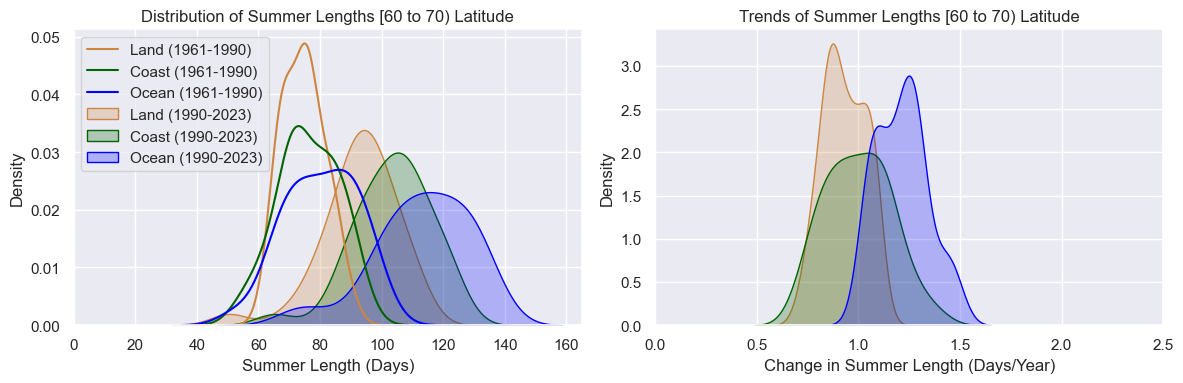

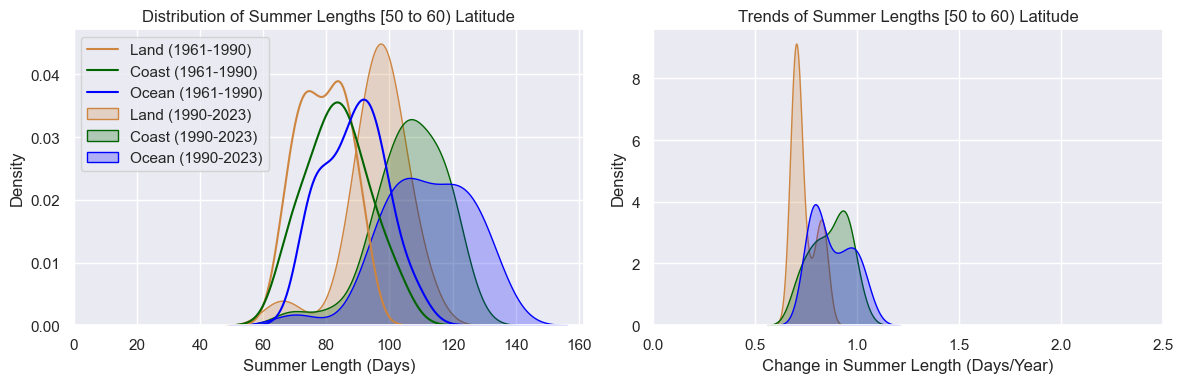

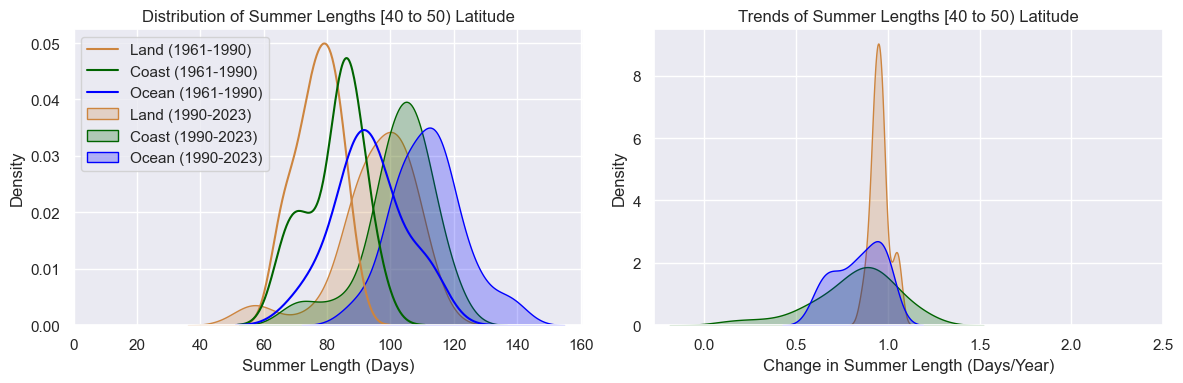

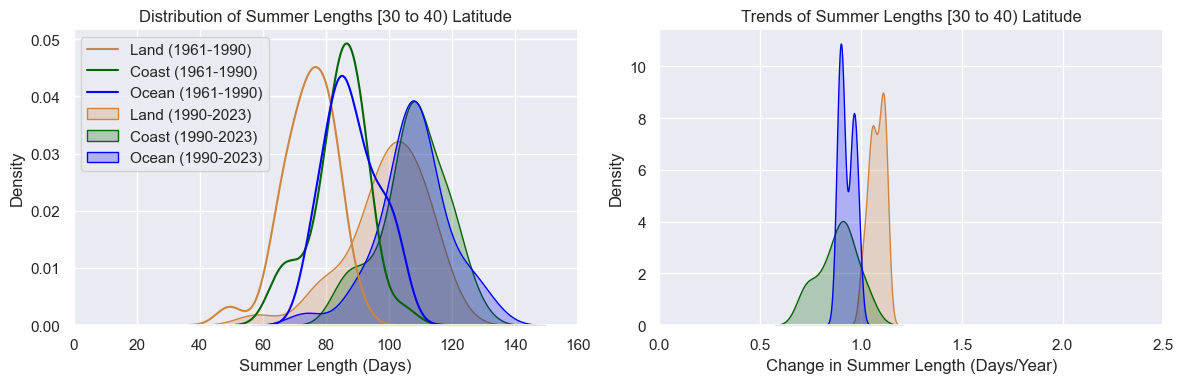

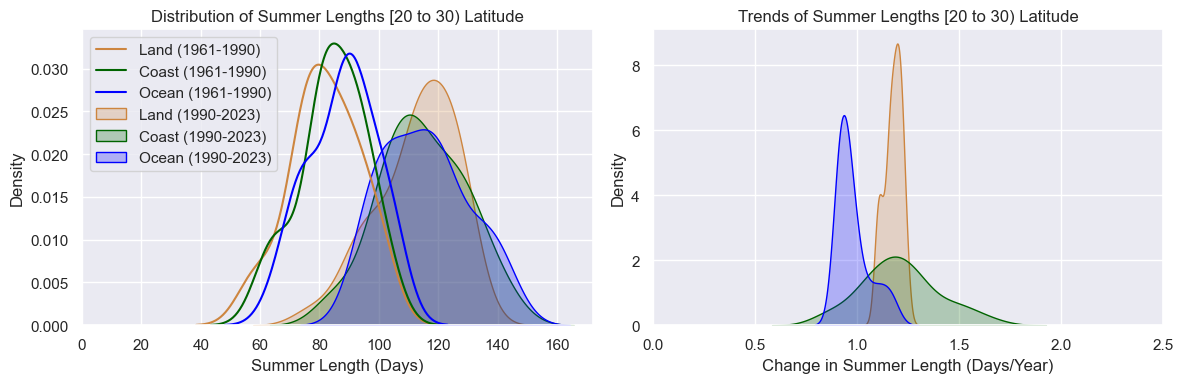

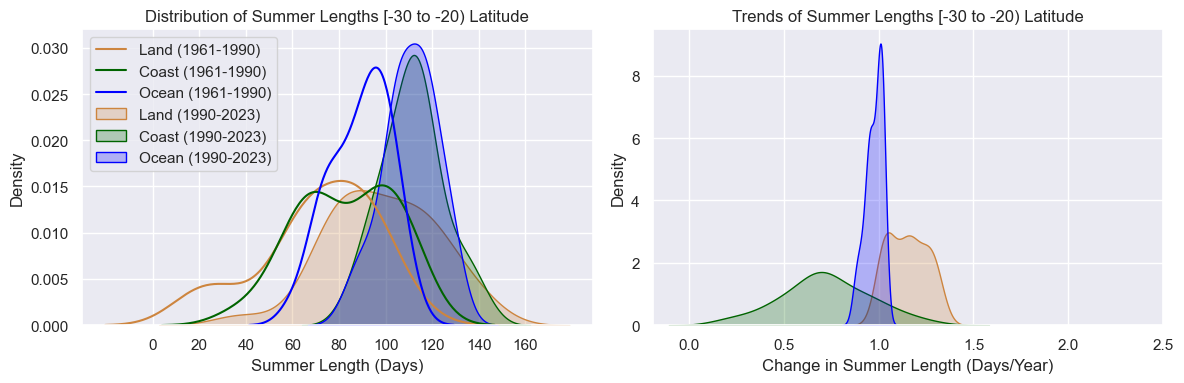

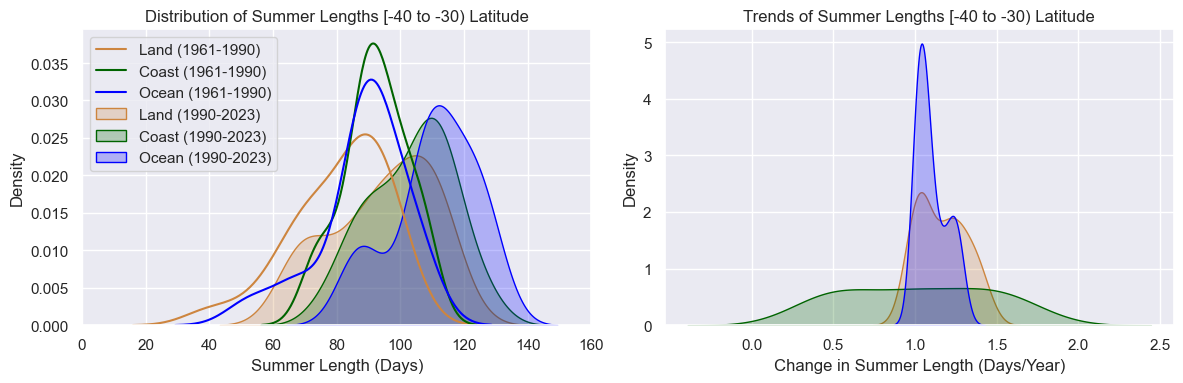

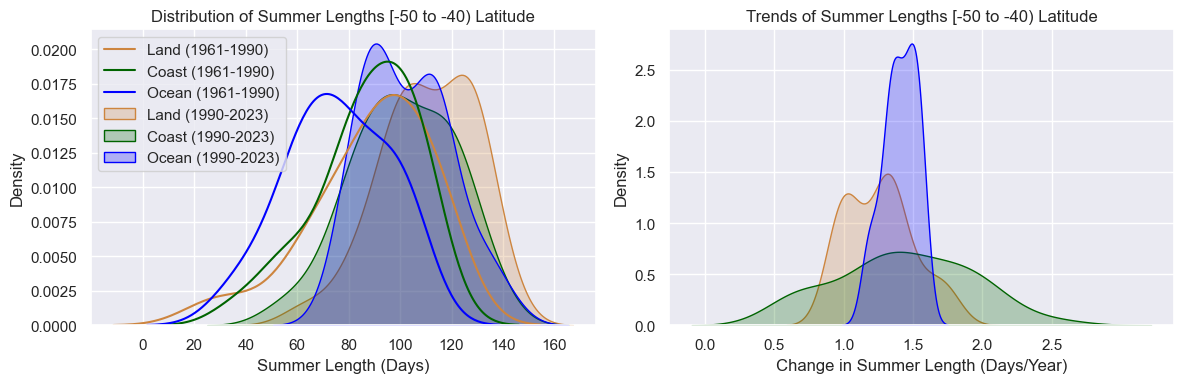

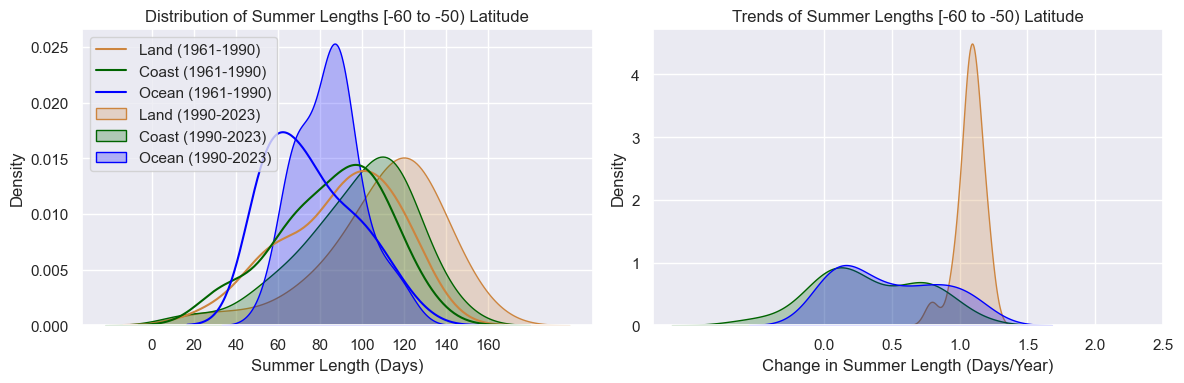

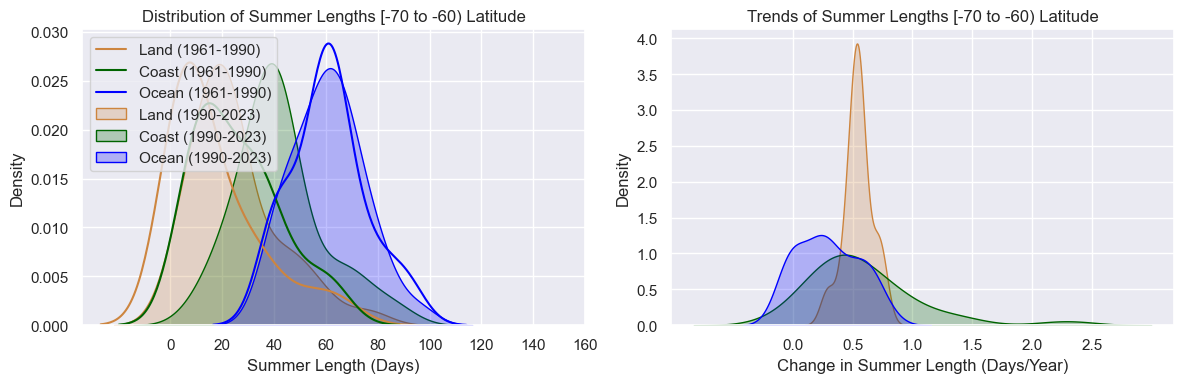

CPU times: user 9.92 s, sys: 4.48 s, total: 14.4 s
Wall time: 14.4 s


In [9]:
%%time



# loop through all latitude buckets
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, KEEPING grid cells from averages where the mean summer temp was 0 K meaning no summer
    land_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                             (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    coast_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_base = ds_full.SummerLength.sel(time=slice('1961','1990')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    ocean_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    land_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & #(ds_full.SummerMeanT > 0) & 
                                                           (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    coast_an = ds_full.SummerLength.sel(time=slice('1990','2023')).where((ds_full.Coastal) & #(ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    # datasets of zonal trends for land, ocean, coasts during analysis period
    land_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm > 0.5) & (ds_2023.Coastal == False) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    coast_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.Coastal) & 
                                             ((ds_length_trends_an.lat >= v) & 
                                              (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    ocean_trends_an = ds_length_trends_an.LengthSlope.where((ds_2023.lsm <= 0.5) & 
                                         ((ds_length_trends_an.lat >= v) & 
                                          (ds_length_trends_an.lat < (v+10)))).mean(dim='lon')

    
    # create blank fig
    fig = plt.figure(figsize = (12,4))
    sns.set_theme(style="darkgrid")
    
    # Length value distributions
    #ax1 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,1)
    sns.kdeplot(land_base, fill=False, color="peru", label="Land (1961-1990)", levels=levels)
    sns.kdeplot(coast_base, fill=False, color="darkgreen", label="Coast (1961-1990)", levels=levels)
    sns.kdeplot(ocean_base, fill=False, color="blue", label="Ocean (1961-1990)", levels=levels)
    sns.kdeplot(land_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax1.set_title("Distribution of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    ax1.legend(loc='upper left')
    ax1.set_xticks(np.arange(0,180,20))
    ax1.set_xlabel("Summer Length (Days)")

    # Length trend distributions
    ax2 = fig.add_subplot(1,2,2)
    sns.kdeplot(land_trends_an, fill=True, color="peru", label="Land (1990-2023)", levels=levels)
    sns.kdeplot(coast_trends_an, fill=True, color="darkgreen", label="Coast (1990-2023)", levels=levels)
    sns.kdeplot(ocean_trends_an, fill=True, color="blue", label="Ocean (1990-2023)", levels=levels)
    ax2.set_title("Trends of Summer Lengths [" + str(v) +" to " + str(v+10) + ") Latitude")
    #ax2.legend(loc='upper left')
    ax2.set_xticks(np.arange(0,3,0.5))
    ax2.set_xlabel("Change in Summer Length (Days/Year)")

    plt.tight_layout()
    plt.show()